In [95]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import RidgeClassifierCV
import numpy as np

In [82]:
df = pd.read_csv("./modified_employee_turnover.csv")

In [4]:
df.describe()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
count,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1.350000e+03,1350.000000,1350.000000
mean,0.506386,0.487061,0.484761,0.499442,0.494884,0.509909,0.504329,0.500164,0.516149,0.506091,0.493360,0.486843,0.485767,3.291479e-01,0.240653,0.497778
std,0.291505,0.283808,0.282758,0.293013,0.289248,0.290110,0.295693,0.294835,0.295072,0.284901,0.292929,0.288342,0.285077,2.986314e-01,0.222281,0.500180
min,0.001738,0.000546,0.001545,0.000166,0.001319,0.005015,0.000424,0.000231,0.000150,0.000903,0.000491,0.001293,0.001595,2.410000e-07,0.000247,0.000000
25%,0.263051,0.238538,0.249651,0.246399,0.244162,0.263235,0.249894,0.239224,0.247978,0.269517,0.247274,0.233357,0.244944,6.114448e-02,0.058694,0.000000
50%,0.525340,0.468457,0.485414,0.495572,0.501617,0.532388,0.509448,0.499964,0.531408,0.504640,0.498490,0.475214,0.468982,2.484923e-01,0.165438,0.000000
75%,0.750987,0.724088,0.721622,0.753108,0.743938,0.761090,0.755113,0.767168,0.775888,0.761640,0.740231,0.747609,0.725870,5.479425e-01,0.367042,1.000000
max,0.998692,0.999957,0.999722,0.999931,0.997813,0.999143,0.999794,0.998365,0.999962,0.999964,0.998211,0.998330,0.999386,9.964245e-01,0.930338,1.000000


### Checking for class imbalance

In [7]:
df["Employee_Turnover"].value_counts()

Employee_Turnover
0    678
1    672
Name: count, dtype: int64

### Checking for multi-collinearity

In [8]:
corr = df.corr()

In [16]:
corr

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
Job_Satisfaction,1.000000,-0.013499,0.018610,-0.015050,-0.009268,-0.040202,-0.014709,-0.030722,-0.016272,0.007917,0.027584,0.014141,0.020369,0.030457,0.055241,0.357116
Performance_Rating,-0.013499,1.000000,0.007091,-0.018917,-0.010547,0.010065,-0.003416,0.040157,0.007017,0.030570,-0.010708,-0.009937,0.034609,-0.016976,-0.038536,0.340058
Years_At_Company,0.018610,0.007091,1.000000,-0.054868,0.032231,-0.008824,-0.018122,0.051595,0.021833,-0.001915,-0.005375,-0.055216,-0.061088,-0.007186,-0.043385,0.296231
Work_Life_Balance,-0.015050,-0.018917,-0.054868,1.000000,0.002759,0.031328,-0.019458,0.020131,0.010430,0.077755,-0.006010,-0.000475,-0.022073,-0.003647,-0.013007,0.298103
Distance_From_Home,-0.009268,-0.010547,0.032231,0.002759,1.000000,-0.031309,0.003328,0.012267,-0.000523,0.012957,-0.015791,-0.001840,-0.109516,-0.010358,-0.002233,0.350905
Monthly_Income,-0.040202,0.010065,-0.008824,0.031328,-0.031309,1.000000,-0.003736,-0.026828,0.022438,-0.081484,-0.012786,-0.043811,-0.001771,-0.027289,-0.058695,-0.033279
Education_Level,-0.014709,-0.003416,-0.018122,-0.019458,0.003328,-0.003736,1.000000,0.011393,0.004723,-0.010007,-0.042444,0.003613,-0.003426,-0.036356,-0.017416,-0.059755
Age,-0.030722,0.040157,0.051595,0.020131,0.012267,-0.026828,0.011393,1.000000,0.017567,0.018512,-0.005362,-0.027564,0.000624,-0.013028,-0.031253,0.024104
Num_Companies_Worked,-0.016272,0.007017,0.021833,0.010430,-0.000523,0.022438,0.004723,0.017567,1.000000,0.006259,0.037511,0.041892,-0.043189,0.040247,0.047014,-0.004040
Employee_Role,0.007917,0.030570,-0.001915,0.077755,0.012957,-0.081484,-0.010007,0.018512,0.006259,1.000000,-0.065750,0.037978,-0.000780,-0.059317,-0.011613,0.064028


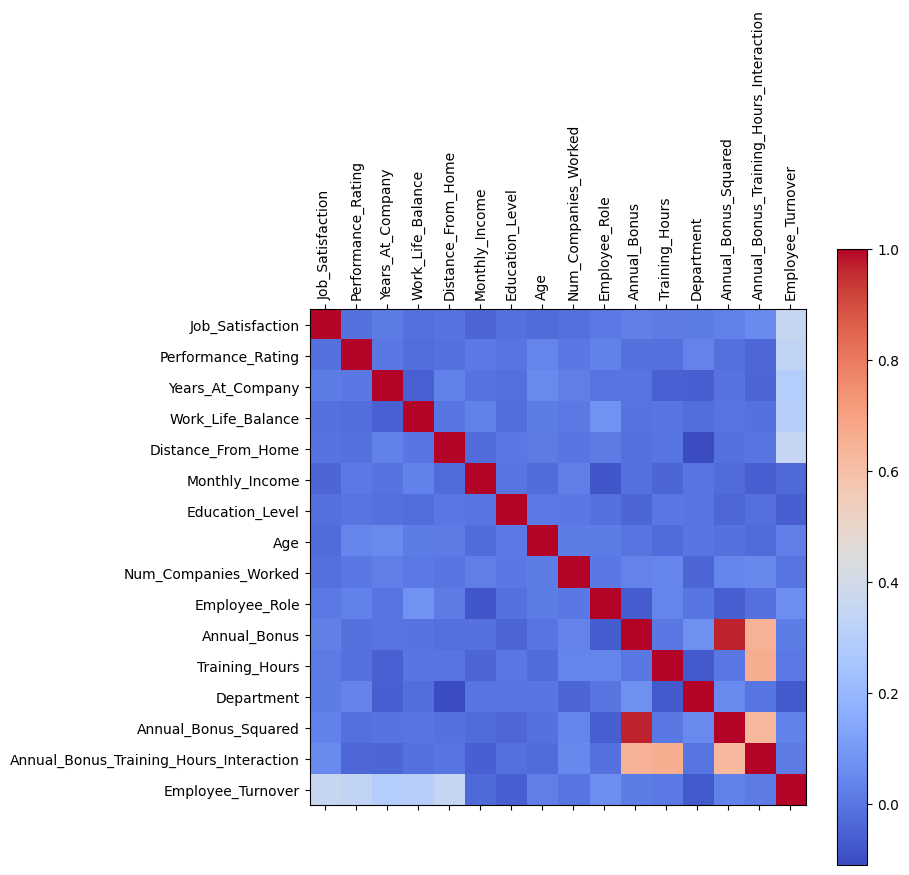

In [15]:
fig, ax = plt.subplots(figsize=(8,8))
cax = ax.matshow(corr, cmap='coolwarm')
fig.colorbar(cax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
plt.show()

In [20]:
df.values[0]

array([0.56232631, 0.14112861, 0.12398891, 0.34758336, 0.33035316,
       0.32885323, 0.60093279, 0.31599016, 0.76873587, 0.09067077,
       0.32478586, 0.66919313, 0.60293211, 0.10548585, 0.21734446,
       0.        ])

In [21]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Features"] = data.columns
    vif_df["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [22]:
calculate_vif(df)

,Features,VIF
0,Job_Satisfaction,4.444286
1,Performance_Rating,4.599046
2,Years_At_Company,4.181857
3,Work_Life_Balance,4.323301
4,Distance_From_Home,4.283765
5,Monthly_Income,3.958783
6,Education_Level,3.733705
7,Age,3.784382
8,Num_Companies_Worked,3.940548
9,Employee_Role,4.001596


In [31]:
df[["Annual_Bonus", "Annual_Bonus_Squared"]]

,Annual_Bonus,Annual_Bonus_Squared
0,0.324786,0.105486
1,0.694611,0.482484
2,0.153476,0.023555
3,0.305973,0.093620
4,0.844094,0.712494
...,...,...
1345,0.450783,0.203205
1346,0.211581,0.044767
1347,0.449095,0.201686
1348,0.649934,0.422414


### Dropping Annual_Bonus, as we have another column named Annual_Bonus_Squared and its VIF value is less than Annual_Bonus

In [32]:
df.drop("Annual_Bonus", axis=1, inplace=True)

In [35]:
train_df, remaining_df = train_test_split(df, test_size=0.3)
test_df, val_df = train_test_split(remaining_df, test_size=0.1)

In [36]:
x_train = train_df.drop("Employee_Turnover", axis=1)
y_train = train_df["Employee_Turnover"]
x_test = test_df.drop("Employee_Turnover", axis=1)
y_test =test_df["Employee_Turnover"]
x_val = val_df.drop("Employee_Turnover", axis=1)
y_val = val_df["Employee_Turnover"]

In [38]:
DT_model = DecisionTreeClassifier().fit(x_train, y_train)

In [50]:
DT_model.get_depth(), DT_model.get_n_leaves(), DT_model.get_params()

(10,
 np.int64(103),
 {'ccp_alpha': 0.0,
  'class_weight': None,
  'criterion': 'gini',
  'max_depth': None,
  'max_features': None,
  'max_leaf_nodes': None,
  'min_impurity_decrease': 0.0,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'min_weight_fraction_leaf': 0.0,
  'monotonic_cst': None,
  'random_state': None,
  'splitter': 'best'})

In [52]:
y_pred = DT_model.predict(x_test)

In [56]:
print(classification_report(y_train, DT_model.predict(x_train)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       468
           1       1.00      1.00      1.00       477

    accuracy                           1.00       945
   macro avg       1.00      1.00      1.00       945
weighted avg       1.00      1.00      1.00       945



In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       191
           1       0.85      0.85      0.85       173

    accuracy                           0.86       364
   macro avg       0.86      0.86      0.86       364
weighted avg       0.86      0.86      0.86       364



### L2 Regularization - RidgeClassifier CV

In [83]:
alphas = np.linspace(0, 10, 20)
alphas

array([ 0.        ,  0.52631579,  1.05263158,  1.57894737,  2.10526316,
        2.63157895,  3.15789474,  3.68421053,  4.21052632,  4.73684211,
        5.26315789,  5.78947368,  6.31578947,  6.84210526,  7.36842105,
        7.89473684,  8.42105263,  8.94736842,  9.47368421, 10.        ])

In [ ]:
ridge_classifier_cv = RidgeClassifierCV(alphas=alphas, cv=10)
ridge_classifier_cv.fit(x_train, y_train)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.",array([ 0. ... 10. ])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`accuracy ` otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",10
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation results corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False


In [ ]:
ridge_classifier_cv.fit(x_train, y_train)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.",array([ 0. ... 10. ])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`accuracy ` otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",10
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation results corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False


In [ ]:
ridge_classifier_cv.alpha_

np.float64(6.842105263157895)

In [ ]:
# R-squared scores for the Ridge model
r2_train_enet = ridge_classifier_cv.score(x_train, y_train)
r2_test_enet = ridge_classifier_cv.score(x_test, y_test)

r2_train_enet, r2_test_enet

(0.8698412698412699, 0.8571428571428571)

### After, comparing the scores of L1, L2 and Elastic Net regularization. We found that L2 regularization is giving the best results.